In [1]:
import torch

In [4]:
torch0d = torch.tensor(0)
torch1d = torch.tensor([1,2,3])
torch2d = torch.tensor([[1,2,3], [4,5,6]])
torch3d = torch.tensor([[[1,2,3], [4,5,6]], [[7,8,9], [10,11,12]]])
print(torch0d)
print(torch1d)
print(torch2d)
print(torch3d)

tensor(0)
tensor([1, 2, 3])
tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])


In [7]:
print(torch0d.dtype)

torch.int64


In [8]:
print(torch1d.to(torch.float32))

tensor([1., 2., 3.])


In [9]:
torch2d.reshape([3,2])

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [10]:
torch2d.view(3,2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [11]:
torch2d.T

tensor([[1, 4],
        [2, 5],
        [3, 6]])

In [12]:
print(torch2d @ torch2d.T)

tensor([[14, 32],
        [32, 77]])


## Seeing models as compute graph

In [3]:
import torch.nn.functional as F

In [5]:
y = torch.tensor([1.0])
x = torch.tensor([1.1])
w = torch.tensor([2.2])
b = torch.tensor([0.0])

z = x * w + b
a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a,y)
loss

tensor(0.0852)

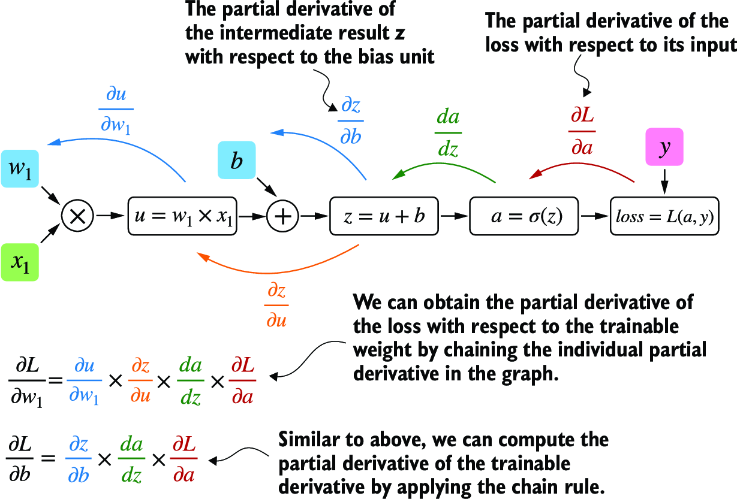

Computing loss gradients by applying the chain rule from the right to the left. Partial derivative of loss w.r.t to trainable weight and partial derivative of loss with respect to bias.

## Computing Gradients via autograd

In [9]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x = torch.tensor([1.1])
w = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x * w + b
a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a, y)

grad_L_w = grad(loss, w, retain_graph=True)
grad_L_b = grad(loss, b, retain_graph=True)
print(grad_L_w)
print(grad_L_b)

loss.backward()
print(w.grad, "<= weight gradient")
print(b.grad, "<= bias gradient")

(tensor([-0.0898]),)
(tensor([-0.0817]),)
tensor([-0.0898]) <= weight gradient
tensor([-0.0817]) <= bias gradient


## Implementing Multilayer Neural Network

To implement a neural network in pytorch we can subclass `torch.nn.Module`. It gives the following features:
- Allows to encapsulate layers and operations
- Keep track of the model's parameters

> In deep learning initializing model weights with small random numbers is desired to break symmetery during training.
> The nodes otherwise perform same operations during backpropagation which would not allow it to learn complex mappins from inputs to outputs.

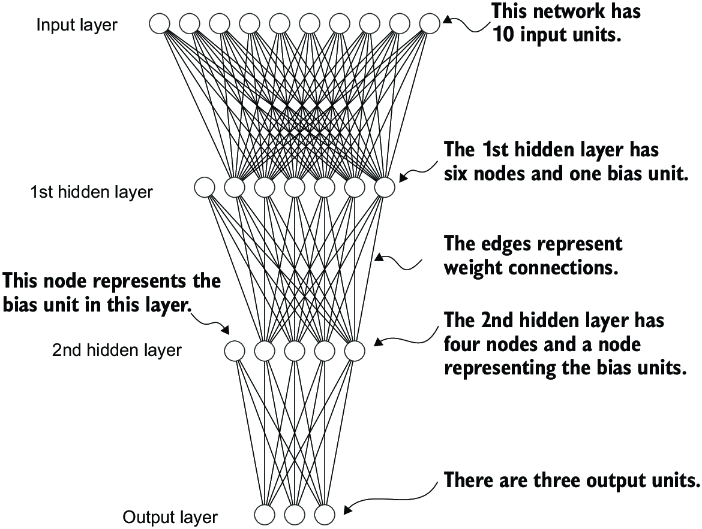

In [2]:
"Multilayer perceptron with two hidden networks"
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.layers = torch.nn.Sequential(
            # 1st hidden layer
            # linear layer multiplies inputs with weights and adds
            # a bias referred to as feedforward or fully-connected 
            # layer.
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            #2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            #output layer
            torch.nn.Linear(20, num_outputs)
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

torch.manual_seed(123)
model = NeuralNetwork(50,3)
print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable parameters=> ", num_params)
print("layer 0 weights dim=>", model.layers[0].weight.shape)
print("layer 0 bias dim =>", model.layers[0].bias.shape)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)
trainable parameters=>  2213
layer 0 weights dim=> torch.Size([30, 50])
layer 0 bias dim => torch.Size([30])


In [4]:
X = torch.rand((1,50))
print(X)
out = model(X)
print(out)

tensor([[0.2391, 0.3194, 0.8111, 0.7507, 0.3306, 0.5374, 0.2845, 0.8459, 0.2232,
         0.2083, 0.8169, 0.1084, 0.3285, 0.7185, 0.3624, 0.3084, 0.8893, 0.4179,
         0.9741, 0.3697, 0.2397, 0.8936, 0.1443, 0.1365, 0.7625, 0.1632, 0.6641,
         0.1525, 0.9830, 0.5936, 0.9120, 0.0146, 0.6323, 0.4743, 0.7467, 0.3545,
         0.9994, 0.9815, 0.7399, 0.2057, 0.8742, 0.0138, 0.7676, 0.7481, 0.7570,
         0.6432, 0.9111, 0.2246, 0.8668, 0.6961]])
tensor([[-0.1670,  0.1001, -0.1219]], grad_fn=<AddmmBackward0>)


In [5]:
"don't use gradients during inference"
with torch.no_grad():
    out = model(X)
print(out)

tensor([[-0.1670,  0.1001, -0.1219]])


## Efficient Data loaders

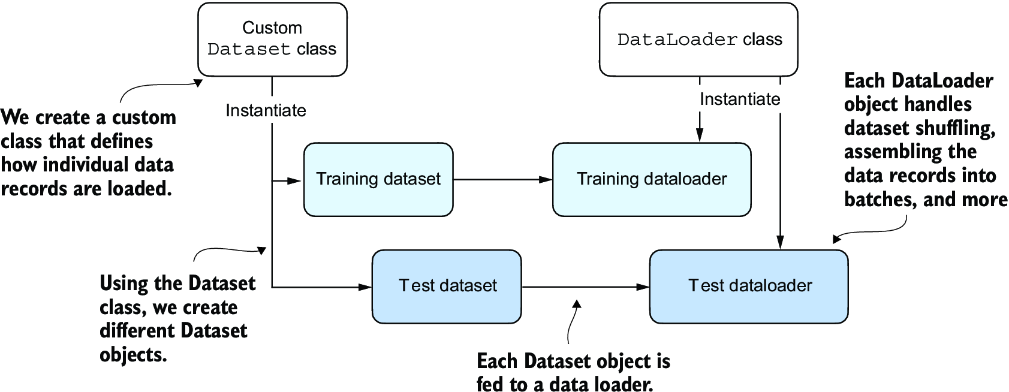

PyTorch implements a Dataset and a DataLoader class. The Dataset class is used to instantiate objects that define how each data record is loaded. The DataLoader handles how the data is shuffled and assembled into batches.

In [6]:
"create a toy dataset"

X_train = torch.tensor([
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])
Y_train = torch.tensor([0, 0, 0, 1, 1])
X_test = torch.tensor([
    [-0.8, 2.8],
    [2.6, -1.6],
])
Y_test = torch.tensor([0,1])

In [7]:
from torch.utils.data import Dataset

class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y

    def __len__(self):
        return self.labels.shape[0]

train_ds = ToyDataset(X_train, Y_train)
test_ds = ToyDataset(X_test, Y_test)


In [8]:
from torch.utils.data import DataLoader

torch.manual_seed(123)

train_loader = DataLoader(
    dataset = train_ds,
    batch_size = 2,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    dataset = test_ds,
    batch_size = 2,
    shuffle = False,
    num_workers = 0
)

for idx, (x,y) in enumerate(train_loader):
    print(f"Batch {idx+1}", x,y)

Batch 1 tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])
Batch 2 tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 3 tensor([[ 2.7000, -1.5000]]) tensor([1])


## Training Loop in Python


In [9]:
import torch.nn.functional as F

torch.manual_seed(123)
model = NeuralNetwork(num_inputs=2, num_outputs=2)
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):
        logits = model(features)
        loss = F.cross_entropy(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### LOGGING
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train Loss: {loss:.2f}")
        
        model.eval()

Epoch: 001/003 | Batch 000/003 | Train Loss: 0.75
Epoch: 001/003 | Batch 001/003 | Train Loss: 0.65
Epoch: 001/003 | Batch 002/003 | Train Loss: 0.42
Epoch: 002/003 | Batch 000/003 | Train Loss: 0.05
Epoch: 002/003 | Batch 001/003 | Train Loss: 0.13
Epoch: 002/003 | Batch 002/003 | Train Loss: 0.00
Epoch: 003/003 | Batch 000/003 | Train Loss: 0.01
Epoch: 003/003 | Batch 001/003 | Train Loss: 0.00
Epoch: 003/003 | Batch 002/003 | Train Loss: 0.02


In [10]:
model.eval()
with torch.no_grad():
    outputs = model(X_train)

print(outputs)

"convert the output into probabilities using softmax"
torch.set_printoptions(sci_mode=False)
probas = torch.softmax(outputs, dim=1)
print(probas)

"convert the output to class using argmax"
predictions = torch.argmax(outputs, dim=1)
print(predictions)

tensor([[ 2.9320, -4.2563],
        [ 2.6045, -3.8389],
        [ 2.1484, -3.2514],
        [-2.1461,  2.1496],
        [-2.5004,  2.5210]])
tensor([[0.9992, 0.0008],
        [0.9984, 0.0016],
        [0.9955, 0.0045],
        [0.0134, 0.9866],
        [0.0066, 0.9934]])
tensor([0, 0, 0, 1, 1])


In [15]:
def compute_accuracy(model, dataloader):
    model.eval() #put it in eval mode
    correct = 0.0
    total_examples = 0

    for idx, (features, labels) in enumerate(dataloader):
        with torch.no_grad():
            outputs = model(features)
        predictions = torch.argmax(outputs, dim=1)
        compare = labels == predictions
        correct += torch.sum(compare)
        total_examples += len(compare)
    return (correct / total_examples).item()
    

In [16]:
print(compute_accuracy(model, train_loader))

1.0


## Saving and Loading Models

In [19]:
"save the model"

torch.save(model.state_dict(), "model.pth")

In [20]:
"load the model "

model = NeuralNetwork(2,2)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

## Optimizing for GPUs